=== SALES SUMMARY ===
Total Quantity Sold: 82
Total Revenue: $34,399.18
Average Sale Amount: $4,299.90

=== PRODUCT PERFORMANCE ===
   product  total_qty  revenue
Smartphone         22 15399.78
    Laptop          8  7999.92
Headphones         40  5999.60
    Tablet          8  3999.92
   Monitor          4   999.96


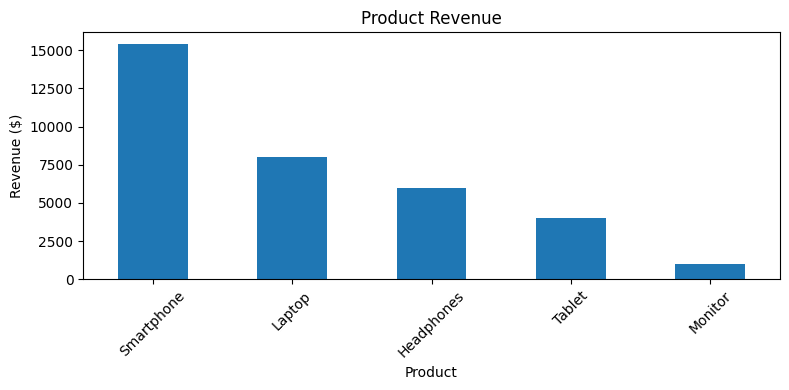

In [23]:
import sqlite3

def create_database():
    conn = sqlite3.connect('sales_data.db')
    cursor = conn.cursor()
    
    # Create sales table if it doesn't exist
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        sale_id INTEGER PRIMARY KEY,
        product_name TEXT,
        quantity INTEGER,
        unit_price REAL,
        sale_date TEXT
    )
    ''')
    
    # Insert sample data if the table is empty
    cursor.execute('SELECT COUNT(*) FROM sales')
    if cursor.fetchone()[0] == 0:
        sales_data = [
            (1, 'Laptop', 5, 999.99, '2023-01-15'),
            (2, 'Smartphone', 12, 699.99, '2023-01-16'),
            (3, 'Headphones', 25, 149.99, '2023-01-17'),
            (4, 'Laptop', 3, 999.99, '2023-01-18'),
            (5, 'Tablet', 8, 499.99, '2023-01-19'),
            (6, 'Smartphone', 10, 699.99, '2023-01-20'),
            (7, 'Monitor', 4, 249.99, '2023-01-21'),
            (8, 'Headphones', 15, 149.99, '2023-01-22')
        ]
        cursor.executemany('INSERT INTO sales VALUES (?, ?, ?, ?, ?)', sales_data)
    
    conn.commit()
    conn.close()

# Create the database and populate it
create_database()
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

def get_sales_summary():
    conn = sqlite3.connect('sales_data.db')
    
    # Verify table exists
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='sales'")
    if not cursor.fetchone():
        raise ValueError("Sales table doesn't exist in the database")
    
    # Query for basic sales metrics
    total_quantity = pd.read_sql('SELECT SUM(quantity) as total_quantity FROM sales', conn)
    total_revenue = pd.read_sql('SELECT SUM(quantity * unit_price) as total_revenue FROM sales', conn)
    avg_sale = pd.read_sql('SELECT AVG(quantity * unit_price) as avg_sale FROM sales', conn)
    
    # Query for product-wise sales
    product_sales = pd.read_sql('''
        SELECT 
            product_name as product, 
            SUM(quantity) as total_qty, 
            SUM(quantity * unit_price) as revenue
        FROM sales
        GROUP BY product_name
        ORDER BY revenue DESC
    ''', conn)
    
    conn.close()
    
    # Display summary
    print("=== SALES SUMMARY ===")
    print(f"Total Quantity Sold: {total_quantity.iloc[0,0]}")
    print(f"Total Revenue: ${total_revenue.iloc[0,0]:,.2f}")
    print(f"Average Sale Amount: ${avg_sale.iloc[0,0]:,.2f}")
    
    print("\n=== PRODUCT PERFORMANCE ===")
    print(product_sales.to_string(index=False))
    
    # Create a simple bar chart
    product_sales.plot(kind='bar', x='product', y='revenue', 
                      title='Product Revenue', 
                      xlabel='Product', 
                      ylabel='Revenue ($)',
                      legend=False,
                      figsize=(8, 4))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("sales_chart.png")
    plt.show()

# Run the sales summary
get_sales_summary()



In [24]:
query = """
SELECT 
    product_name AS product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * unit_price) AS revenue 
FROM sales 
GROUP BY product_name
ORDER BY revenue DESC
"""

In [25]:
df = pd.read_sql_query(query, conn)

In [27]:
print("Sales Summary:")
print(df.to_string(index=False))

Sales Summary:
   product  total_qty  revenue
Smartphone         22 15399.78
    Laptop          8  7999.92
Headphones         40  5999.60
    Tablet          8  3999.92
   Monitor          4   999.96


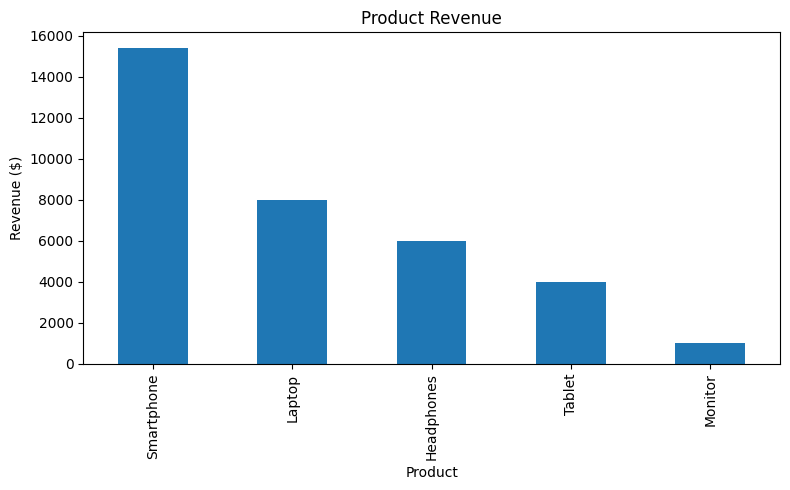

In [28]:
# Plotting
df.plot(kind='bar', x='product', y='revenue',
        title='Product Revenue',
        xlabel='Product',
        ylabel='Revenue ($)',
        legend=False,
        figsize=(8,5))
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()